# WellMind AI - 1. Data Preprocessing

Cleans the raw sleep/lifestyle dataset, builds the wellness scores and target, then saves train/test files for the other notebooks to use.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import sys
from pathlib import Path
_nb = Path.cwd()
sys.path.insert(0, str(_nb if (_nb / "paths.py").exists() else _nb / "notebook"))
from paths import (
    RAW_CSV, TRAIN_CSV, TEST_CSV, TEST_TARGETS_CSV,
    ARTIFACTS_DIR, ENCODERS_PKL, SCALER_PKL, NUM_FEATURE_COLS_PKL, FEATURE_COLS_PKL,
)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

RANDOM_STATE = 42


## 1. Load & Inspect

In [2]:
df = pd.read_csv(RAW_CSV)

print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nData types:")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
df.head()


Shape: (15000, 13)

Columns: ['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps', 'Sleep Disorder']

Data types:
Person ID                    int64
Gender                      object
Age                          int64
Occupation                  object
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                object
Blood Pressure              object
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder              object
dtype: object

Missing values per column:
Person ID                  0
Gender                     0
Age                        0
Occupation                 0
Sleep Duration             0
Quality of Sleep           0
Physical Activity Level    0
Stress Level               0
BMI Category          

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,35,Doctor,6.65,7,50,7,Normal Weight,120/80,71,7100,Healthy
1,2,Male,42,Teacher,6.90,8,52,4,Normal,135/90,66,7000,Healthy
2,3,Male,34,Software Engineer,6.95,7,66,6,Overweight,126/83,74,6100,Healthy
3,4,Male,32,Doctor,6.90,6,52,7,Normal,120/80,71,6500,Healthy
4,5,Male,37,Lawyer,6.85,7,60,6,Normal,125/80,71,6500,Healthy


## 2. Clean Text / Number Formatting

In [3]:
for col in df.select_dtypes(include="object").columns:
    print(col, "-> sample values:", df[col].unique()[:5])

Gender -> sample values: ['Male' 'Female']
Occupation -> sample values: ['Doctor' 'Teacher' 'Software Engineer' 'Lawyer' 'Engineer']
BMI Category -> sample values: ['Normal Weight' 'Normal' 'Overweight' 'Obese']
Blood Pressure -> sample values: ['120/80' '135/90' '126/83' '125/80' '130/85']
Sleep Disorder -> sample values: ['Healthy' 'Sleep Apnea' 'Insomnia']


## 3. Fix Category Errors Before Imputation

In [4]:
gender_map = {"m": "Male", "male": "Male", "f": "Female", "female": "Female"}
df["Gender"] = df["Gender"].str.lower().map(gender_map).fillna(df["Gender"].str.title())

bmi_map = {
    "normal": "Normal Weight",
    "normal weight": "Normal Weight",
    "overweight": "Overweight",
    "obese": "Obese",
}
df["BMI Category"] = df["BMI Category"].str.lower().map(bmi_map).fillna(df["BMI Category"])

df["Occupation"] = df["Occupation"].str.title()
df["Sleep Disorder"] = df["Sleep Disorder"].str.title()
df["Sleep Disorder"] = df["Sleep Disorder"].replace({"Nan": "None"})

if "Blood Pressure" in df.columns:
    bp_split = df["Blood Pressure"].str.split("/", expand=True)
    df["Systolic BP"] = pd.to_numeric(bp_split[0], errors="coerce")
    df["Diastolic BP"] = pd.to_numeric(bp_split[1], errors="coerce")
    df = df.drop(columns=["Blood Pressure"])

print(df["Gender"].value_counts())
print(df["BMI Category"].value_counts())


Gender
Female    8569
Male      6431
Name: count, dtype: int64
BMI Category
Overweight       8755
Normal Weight    5586
Obese             659
Name: count, dtype: int64


## 4. Impute Missing Values

In [5]:
print("Missing values :")
print(df.isnull().sum())




Missing values :
Person ID                  0
Gender                     0
Age                        0
Occupation                 0
Sleep Duration             0
Quality of Sleep           0
Physical Activity Level    0
Stress Level               0
BMI Category               0
Heart Rate                 0
Daily Steps                0
Sleep Disorder             0
Systolic BP                0
Diastolic BP               0
dtype: int64


## 5. Remove Duplicates

In [6]:
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print(f"Removed {before - after} duplicate rows")

if "Person ID" in df.columns:
    df = df.drop(columns=["Person ID"])

Removed 0 duplicate rows


## 6. Feature Engineering - Build the Wellness Scores and Target

Turn the raw lifestyle columns into 0-100 scores, combine them into one
**Wellness Score**, then turn that into a **Lifestyle Category**
(Poor / Average / Healthy). This category is the label we will predict later.

In [7]:
def sleep_hours_points(hours):
    if hours < 5:
        return 30
    elif hours < 7:
        return 55
    elif hours <= 9:
        return 90
    else:
        return 70

df["Sleep Score"] = df["Sleep Duration"].apply(sleep_hours_points) * 0.5 + (df["Quality of Sleep"] / 10 * 100) * 0.5

pal_norm = ((df["Physical Activity Level"].clip(30, 90) - 30) / 60) * 100
steps_norm = (df["Daily Steps"] / 10000 * 100).clip(0, 100)
df["Activity Score"] = pal_norm * 0.5 + steps_norm * 0.5

df["Stress Index"] = df["Stress Level"] * 10

df["Fatigue Score"] = (100 - df["Sleep Score"]) * 0.4 + df["Stress Index"] * 0.35 + (100 - df["Activity Score"]) * 0.25

df["Wellness Score"] = (
    df["Sleep Score"] * 0.35
    + df["Activity Score"] * 0.30
    + (100 - df["Stress Index"]) * 0.20
    + (100 - df["Fatigue Score"]) * 0.15
)
df["Wellness Score"] = df["Wellness Score"].clip(0, 100)

# Small random noise so the target is not a perfect formula of the raw inputs
np.random.seed(RANDOM_STATE)
noisy_wellness = df["Wellness Score"] + np.random.normal(0, 3, size=len(df))
df["Lifestyle Category"] = pd.cut(noisy_wellness, bins=[-1, 50, 75, 101], labels=["Poor", "Average", "Healthy"])

print(df["Lifestyle Category"].value_counts())
df[["Sleep Score", "Activity Score", "Stress Index", "Fatigue Score", "Wellness Score", "Lifestyle Category"]].head()


Lifestyle Category
Average    8921
Poor       4103
Healthy    1976
Name: count, dtype: int64


,Sleep Score,Activity Score,Stress Index,Fatigue Score,Wellness Score,Lifestyle Category
0,62.5,52.166667,70,51.458333,50.80625,Average
1,67.5,53.333333,40,38.666667,60.82500,Average
2,62.5,60.500000,60,45.875000,56.14375,Average
3,57.5,50.833333,70,53.791667,48.30625,Average
4,62.5,57.500000,60,46.625000,55.13125,Average


## 7. Train / Test Split

In [8]:
feature_cols = [
    "Age", "Gender", "Occupation", "Sleep Duration", "Quality of Sleep",
    "Physical Activity Level", "Stress Level", "BMI Category", "Daily Steps", "Sleep Disorder",
]

X = df[feature_cols].copy()
y = df["Lifestyle Category"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (12000, 10)
Test size: (3000, 10)


## 8. Outliers (IQR Capping)

In [9]:
def cap_iqr(series, low_bound=None, high_bound=None):
    if low_bound is None:
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        low_bound = q1 - 1.5 * iqr
        high_bound = q3 + 1.5 * iqr
    return series.clip(low_bound, high_bound), low_bound, high_bound

num_feature_cols = X_train.select_dtypes(include=np.number).columns

for col in num_feature_cols:
    X_train[col], low, high = cap_iqr(X_train[col])
    X_test[col] = X_test[col].clip(low, high)

print("Outlier capping done, using bounds learned from the training data only.")


Outlier capping done, using bounds learned from the training data only.


## 9. Label Encoding

In [10]:
cat_feature_cols = ["Gender", "Occupation", "BMI Category", "Sleep Disorder"]
encoders = {}

for col in cat_feature_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col] = X_test[col].astype(str).apply(lambda v: v if v in le.classes_ else le.classes_[0])
    X_test[col] = le.transform(X_test[col])
    encoders[col] = le
    print(f"Encoded {col}: {list(le.classes_)}")


Encoded Gender: ['Female', 'Male']
Encoded Occupation: ['Accountant', 'Doctor', 'Engineer', 'Lawyer', 'Manager', 'Nurse', 'Sales Representative', 'Salesperson', 'Scientist', 'Software Engineer', 'Teacher']
Encoded BMI Category: ['Normal Weight', 'Obese', 'Overweight']
Encoded Sleep Disorder: ['Healthy', 'Insomnia', 'Sleep Apnea']


## 10. Class Balance Check

Class counts in the training data:
Lifestyle Category
Average    7137
Poor       3282
Healthy    1581
Name: count, dtype: int64


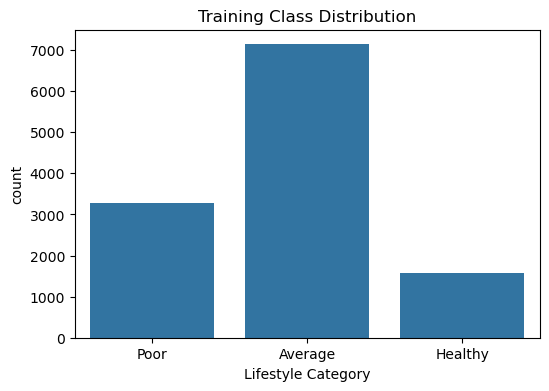

In [11]:
print("Class counts in the training data:")
print(y_train.value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x=y_train)
plt.title("Training Class Distribution")
plt.show()


## 11. Feature Scaling

In [12]:
scaler = StandardScaler()
X_train[num_feature_cols] = scaler.fit_transform(X_train[num_feature_cols])
X_test[num_feature_cols] = scaler.transform(X_test[num_feature_cols])

print("Feature scaling done.")
X_train.head()


Feature scaling done.


,Age,Gender,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Daily Steps,Sleep Disorder
12081,-0.020014,0,7,-0.969973,-1.070154,-0.887873,0.245250,2,-0.598531,1
10651,-0.020014,1,7,-1.051127,-1.070154,-0.887873,0.962528,2,-0.598531,1
5239,1.439970,0,5,0.166191,0.826022,1.307091,0.245250,2,1.276097,2
7519,0.855977,0,5,-1.456900,-1.070154,1.781678,1.679807,2,2.400874,2
11799,-0.020014,0,7,-0.564200,-1.070154,-1.303136,0.245250,2,-0.598531,1


## 12. Final Checks & Save

Save the processed train/test files, plus the encoders and scaler, so the
training notebook and the inference notebook can reuse them.

In [16]:
assert X_train.isnull().sum().sum() == 0, "Train still has missing values"
assert X_test.isnull().sum().sum() == 0, "Test still has missing values"

train_out = X_train.copy()
train_out["Lifestyle Category"] = y_train.values
test_out = X_test.copy()

train_out.to_csv(TRAIN_CSV, index=False)
test_out.to_csv(TEST_CSV, index=False)
pd.DataFrame({"Lifestyle Category": y_test.values}).to_csv(TEST_TARGETS_CSV, index=False)

joblib.dump(encoders, ENCODERS_PKL)
joblib.dump(scaler, SCALER_PKL)
joblib.dump(list(num_feature_cols), NUM_FEATURE_COLS_PKL)
joblib.dump(feature_cols, FEATURE_COLS_PKL)

print(f"Saved: {TRAIN_CSV.name}, {TEST_CSV.name}, {TEST_TARGETS_CSV.name}")
print(f"Artifacts: {ARTIFACTS_DIR}")


Saved: train_processed.csv, test_processed.csv, test_targets.csv
Saved: encoders.pkl, scaler.pkl, num_feature_cols.pkl, feature_cols.pkl
